In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("cleaned_combined.csv")
df

,Carrier Code,destination_code,Scheduled elapsed time (Minutes),Actual elapsed time (Minutes),Departure delay (Minutes),Taxi-Out time (Minutes),origin_code,month,day_of_week,scheduled_hour,...,dest_PRCP,dest_SNDP,dest_SLP,dest_ELEVATION,dest_Fog,dest_Rain,dest_Snow,dest_Hail,dest_Thunder,dest_Tornado
0,1,47,110.0,92.0,12.0,12.0,53,1.0,0.0,13.0,...,0.02,0.0,1020.3,191.9,0.0,1.0,1.0,0.0,0.0,0.0
1,1,159,325.0,291.0,-5.0,23.0,53,1.0,0.0,7.0,...,0.00,0.0,1023.3,1288.4,0.0,0.0,0.0,0.0,0.0,0.0
2,1,117,184.0,152.0,-10.0,13.0,53,1.0,0.0,12.0,...,0.02,1.2,1026.8,254.5,0.0,0.0,0.0,0.0,0.0,0.0
3,1,117,194.0,161.0,4.0,20.0,53,1.0,0.0,18.0,...,0.02,1.2,1026.8,254.5,0.0,0.0,0.0,0.0,0.0,0.0
4,1,159,330.0,278.0,18.0,17.0,53,1.0,0.0,18.0,...,0.00,0.0,1023.3,1288.4,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3966857,2,42,105.0,110.0,-6.0,27.0,81,12.0,6.0,9.0,...,0.00,0.0,1011.1,1647.2,0.0,0.0,0.0,0.0,0.0,0.0
3966858,2,127,120.0,101.0,161.0,9.0,81,12.0,0.0,7.0,...,0.47,0.0,1007.0,204.8,0.0,0.0,0.0,0.0,0.0,0.0
3966859,2,42,105.0,152.0,-2.0,71.0,81,12.0,0.0,9.0,...,0.00,0.0,1005.0,1647.2,0.0,0.0,0.0,0.0,0.0,0.0
3966860,2,127,120.0,128.0,-2.0,15.0,81,12.0,1.0,7.0,...,0.23,0.0,1005.7,204.8,0.0,1.0,0.0,0.0,0.0,0.0


# EDA 

In [55]:
print(df.shape)
print(df.info())
print(df.describe())

(3966862, 43)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3966862 entries, 0 to 3966861
Data columns (total 43 columns):
 #   Column                            Dtype  
---  ------                            -----  
 0   Carrier Code                      int64  
 1   destination_code                  int64  
 2   Scheduled elapsed time (Minutes)  float64
 3   Actual elapsed time (Minutes)     float64
 4   Departure delay (Minutes)         float64
 5   Taxi-Out time (Minutes)           float64
 6   origin_code                       int64  
 7   month                             float64
 8   day_of_week                       float64
 9   scheduled_hour                    float64
 10  weather_delayed                   int64  
 11  origin_TEMP                       float64
 12  origin_DEWP                       float64
 13  origin_VISIB                      float64
 14  origin_WDSP                       float64
 15  origin_MXSPD                      float64
 16  origin_GUST           

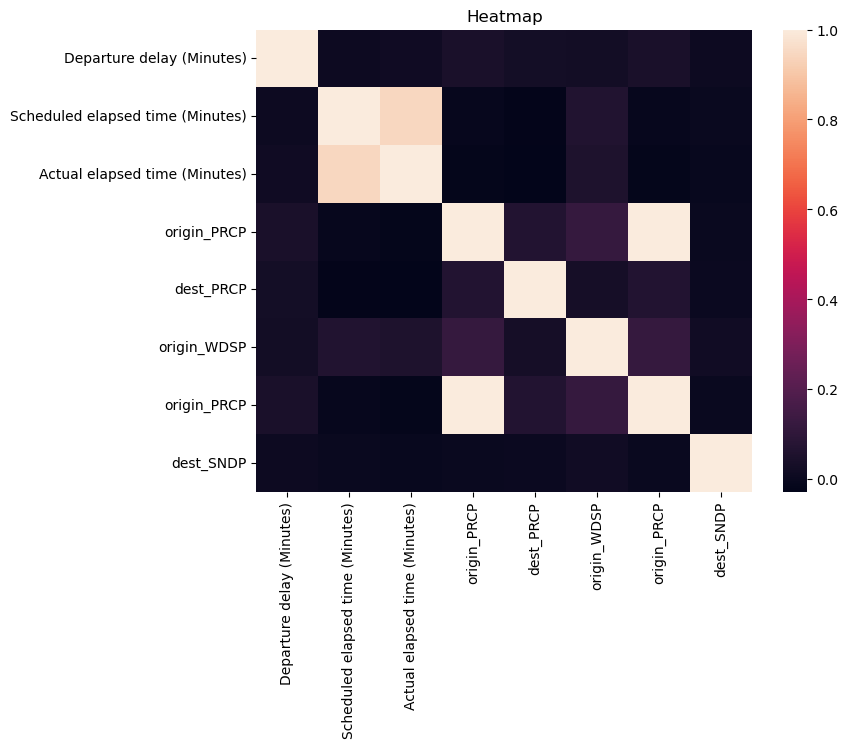

In [64]:
cols = ['Departure delay (Minutes)', 'Scheduled elapsed time (Minutes)', 'Actual elapsed time (Minutes)',
        'origin_PRCP', 'dest_PRCP', 'origin_WDSP', 'origin_PRCP', 'dest_SNDP']
df_heatmap = df[cols]

# 3. Generate and display the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(data=df_heatmap.corr())
plt.title('Heatmap')
plt.show()

# Pretty weak correlations with chosen features

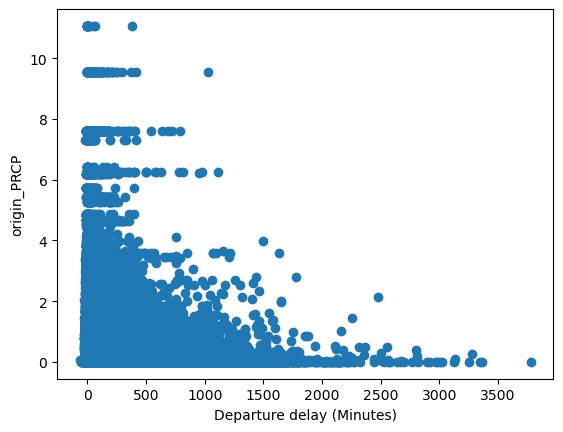

In [94]:

plt.scatter(df['Departure delay (Minutes)'], df['origin_PRCP'])

plt.xlabel("Departure delay (Minutes)")
plt.ylabel("origin_PRCP")

plt.show()


In [89]:
from scipy.stats import linregress
slope, intercept, r_value, p_value, std_err = linregress(df['Departure delay (Minutes)'], df['origin_PRCP'])
r_squared = r_value**2
r_squared

# small r^2 value, meaning no correlation

np.float64(0.001888471123555397)

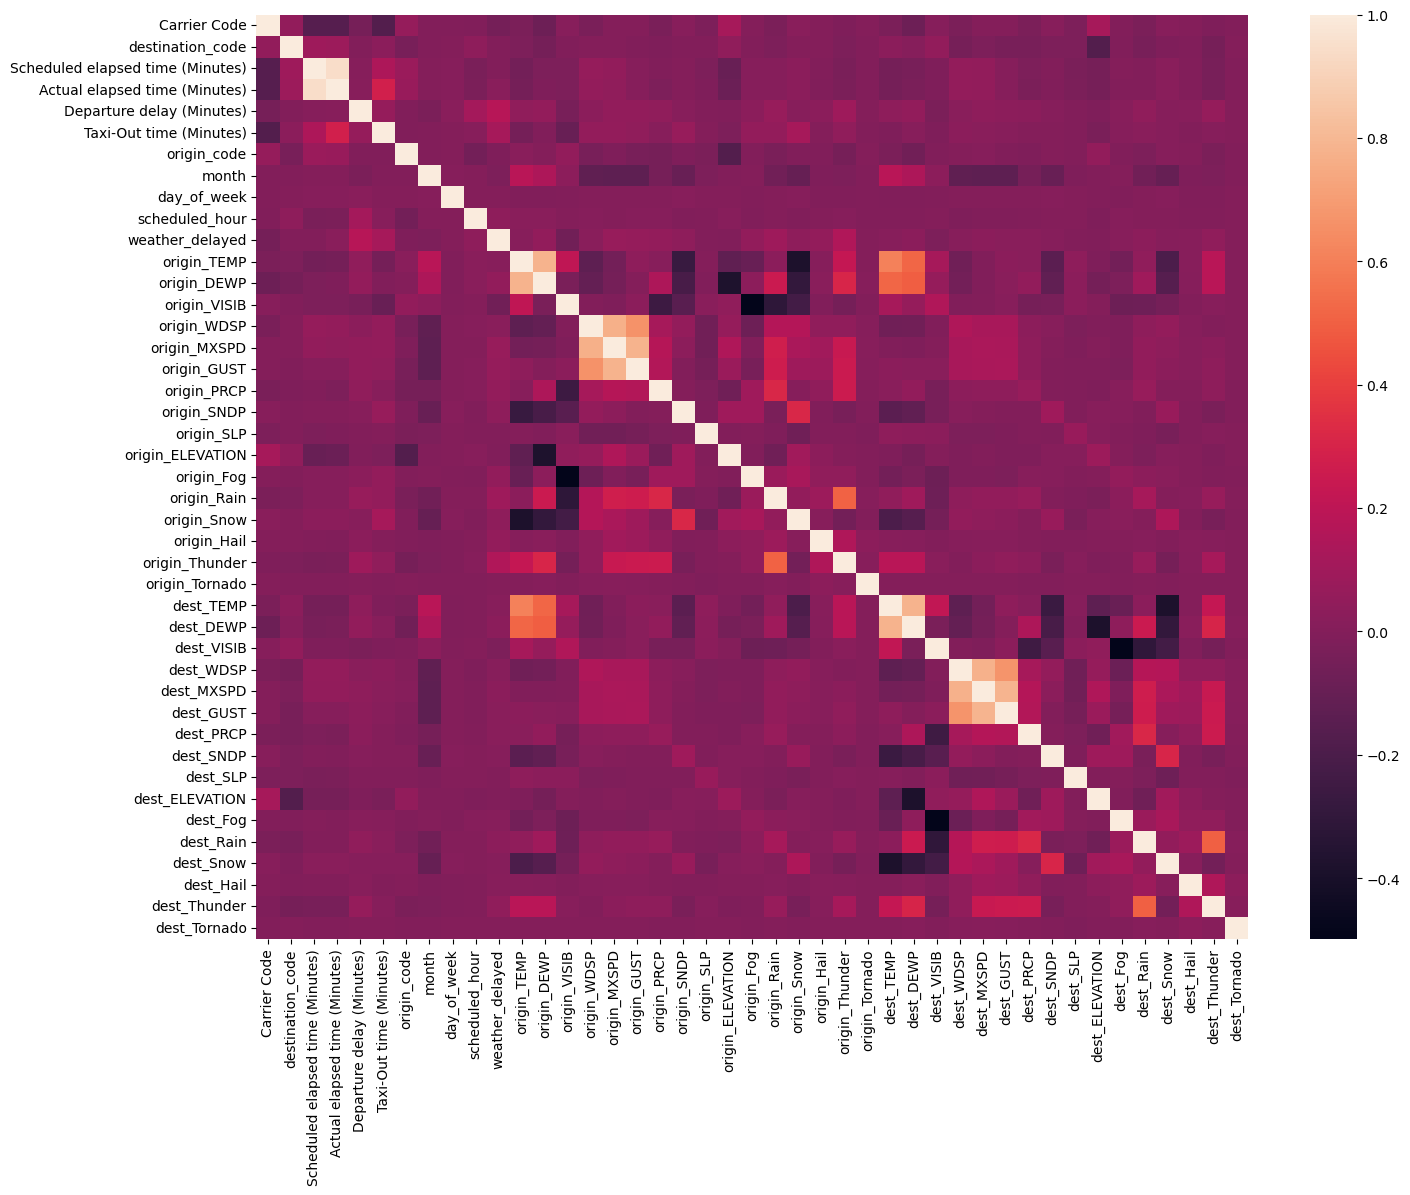

In [92]:
plt.figure(figsize=(16, 12))
sns.heatmap(data=df.corr())
plt.show()

# not super helpful, most correlations are between the weather data items themselves, not delay in minutes

In [84]:
numeric_df = df.select_dtypes(include=np.number)
corr = numeric_df.corr()['Departure delay (Minutes)'].sort_values(ascending=False)
print(corr)

# weak correlations between variables are delay in minutes

Departure delay (Minutes)           1.000000
weather_delayed                     0.178656
scheduled_hour                      0.114195
origin_Thunder                      0.092115
origin_Rain                         0.063826
Taxi-Out time (Minutes)             0.061120
dest_Thunder                        0.060971
origin_DEWP                         0.057865
origin_MXSPD                        0.049306
origin_GUST                         0.048661
dest_DEWP                           0.048140
dest_Rain                           0.044738
origin_PRCP                         0.043457
origin_TEMP                         0.042915
dest_TEMP                           0.036665
dest_MXSPD                          0.034750
dest_GUST                           0.033114
dest_PRCP                           0.027822
origin_Fog                          0.026276
origin_WDSP                         0.023885
origin_Hail                         0.023048
day_of_week                         0.020871
dest_WDSP 

<Axes: xlabel='Carrier Code', ylabel='Departure delay (Minutes)'>

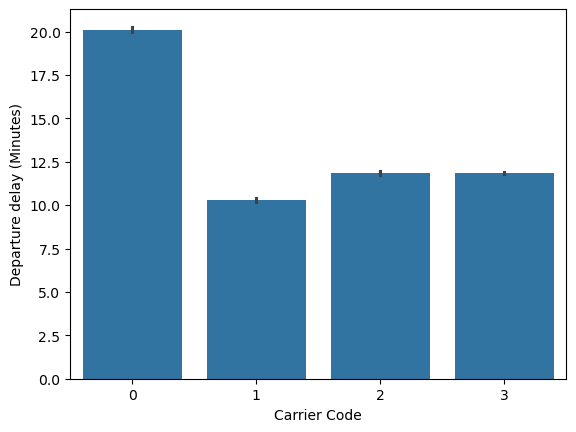

In [96]:
sns.barplot(df, x='Carrier Code', y='Departure delay (Minutes)')

# Carrier mapping: {0: 'AA', 1: 'DL', 2: 'UA', 3: 'WN'}
# American Airlines has an average delay in minutes that is longer than the rest of the airlines (almost double)

In [10]:
average_delay_per_airport = df.groupby(['origin_code'])['Departure delay (Minutes)'].mean().reset_index()
average_delay_per_airport.sort_values(by='Departure delay (Minutes)', ascending=False)

# Longest weather delays on average
# 87 - 'ITO' Hilo International Airport in Hawaii
# 43 - 'DEN' Denver International Airport
# 110 - 'MIA' Miami International Airport

,origin_code,Departure delay (Minutes)
42,87,24.946038
25,43,23.368849
54,110,21.738449
18,33,20.550150
39,80,17.174758
...,...,...
8,15,6.657143
30,56,5.978698
36,74,5.268844
7,14,3.725722


In [123]:
cols = ['origin_code','Departure delay (Minutes)']
max_delay_per_airport = df[cols]
max_delay_per_airport.sort_values(by='Departure delay (Minutes)', ascending=False)

,origin_code,Departure delay (Minutes)
2730731,7,3777.0
1716563,154,3360.0
2530477,147,3348.0
3727868,160,3274.0
3893555,67,3250.0
...,...,...
2947218,118,-49.0
126554,155,-49.0
125474,155,-52.0
1112910,110,-59.0


In [11]:
month_and_delays = df.groupby(['month'])['Departure delay (Minutes)'].mean().reset_index()
month_and_delays.sort_values(by='Departure delay (Minutes)', ascending=False)

# July, May, and June have the highest average weather delays which is a little surprising. 

,month,Departure delay (Minutes)
6,7.0,24.691830
4,5.0,20.237729
5,6.0,18.322111
7,8.0,15.771205
0,1.0,14.738095
2,3.0,13.426545
11,12.0,13.160641
3,4.0,11.764775
1,2.0,7.689993
8,9.0,6.959271


# ML

Only used for SGD, etc. not linear regression

from sklearn.preprocessing import MinMaxScaler

def numeric_scaler(X_train, X_test, y_train, y_test):
    minmax_scaler = MinMaxScaler()
    X_train=minmax_scaler.fit_transform(X_train)
    X_test=minmax_scaler.fit_transform(X_test)

    y_train=minmax_scaler.fit_transform(y_train.reshape(1,-1))
    y_test=minmax_scaler.fit_transform(y_test)

    return X_train, X_test, y_train, y_test

In [127]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3966862 entries, 0 to 3966861
Data columns (total 43 columns):
 #   Column                            Dtype  
---  ------                            -----  
 0   Carrier Code                      int64  
 1   destination_code                  int64  
 2   Scheduled elapsed time (Minutes)  float64
 3   Actual elapsed time (Minutes)     float64
 4   Departure delay (Minutes)         float64
 5   Taxi-Out time (Minutes)           float64
 6   origin_code                       int64  
 7   month                             float64
 8   day_of_week                       float64
 9   scheduled_hour                    float64
 10  weather_delayed                   int64  
 11  origin_TEMP                       float64
 12  origin_DEWP                       float64
 13  origin_VISIB                      float64
 14  origin_WDSP                       float64
 15  origin_MXSPD                      float64
 16  origin_GUST                       fl

In [3]:
df = pd.get_dummies(df, columns=['Carrier Code'], drop_first=True)
df = pd.get_dummies(df, columns=['destination_code'], drop_first=True)
df = pd.get_dummies(df, columns=['origin_code'], drop_first=True)
df = pd.get_dummies(df, columns=['scheduled_hour'], drop_first=True)

In [ ]:
X = df.drop(['Departure delay (Minutes)',
            'Scheduled elapsed time (Minutes)', 'Actual elapsed time (Minutes)',
             'Taxi-Out time (Minutes)', 'month', 'day_of_week',
             'weather_delayed', 
            ], axis=1)
y = df['Departure delay (Minutes)']

# convert dataframes to numpy arrays
X = X.to_numpy()
y = y.to_numpy()

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

#### Construct model
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# fit model
reg = LinearRegression().fit(X_train, y_train)

# evaluate on the test data
y_pred = reg.predict(X_test)

# there is a built-in command to compute the error
mse = mean_squared_error(y_test, y_pred)
print(mse)

from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred) #

print(mae)
